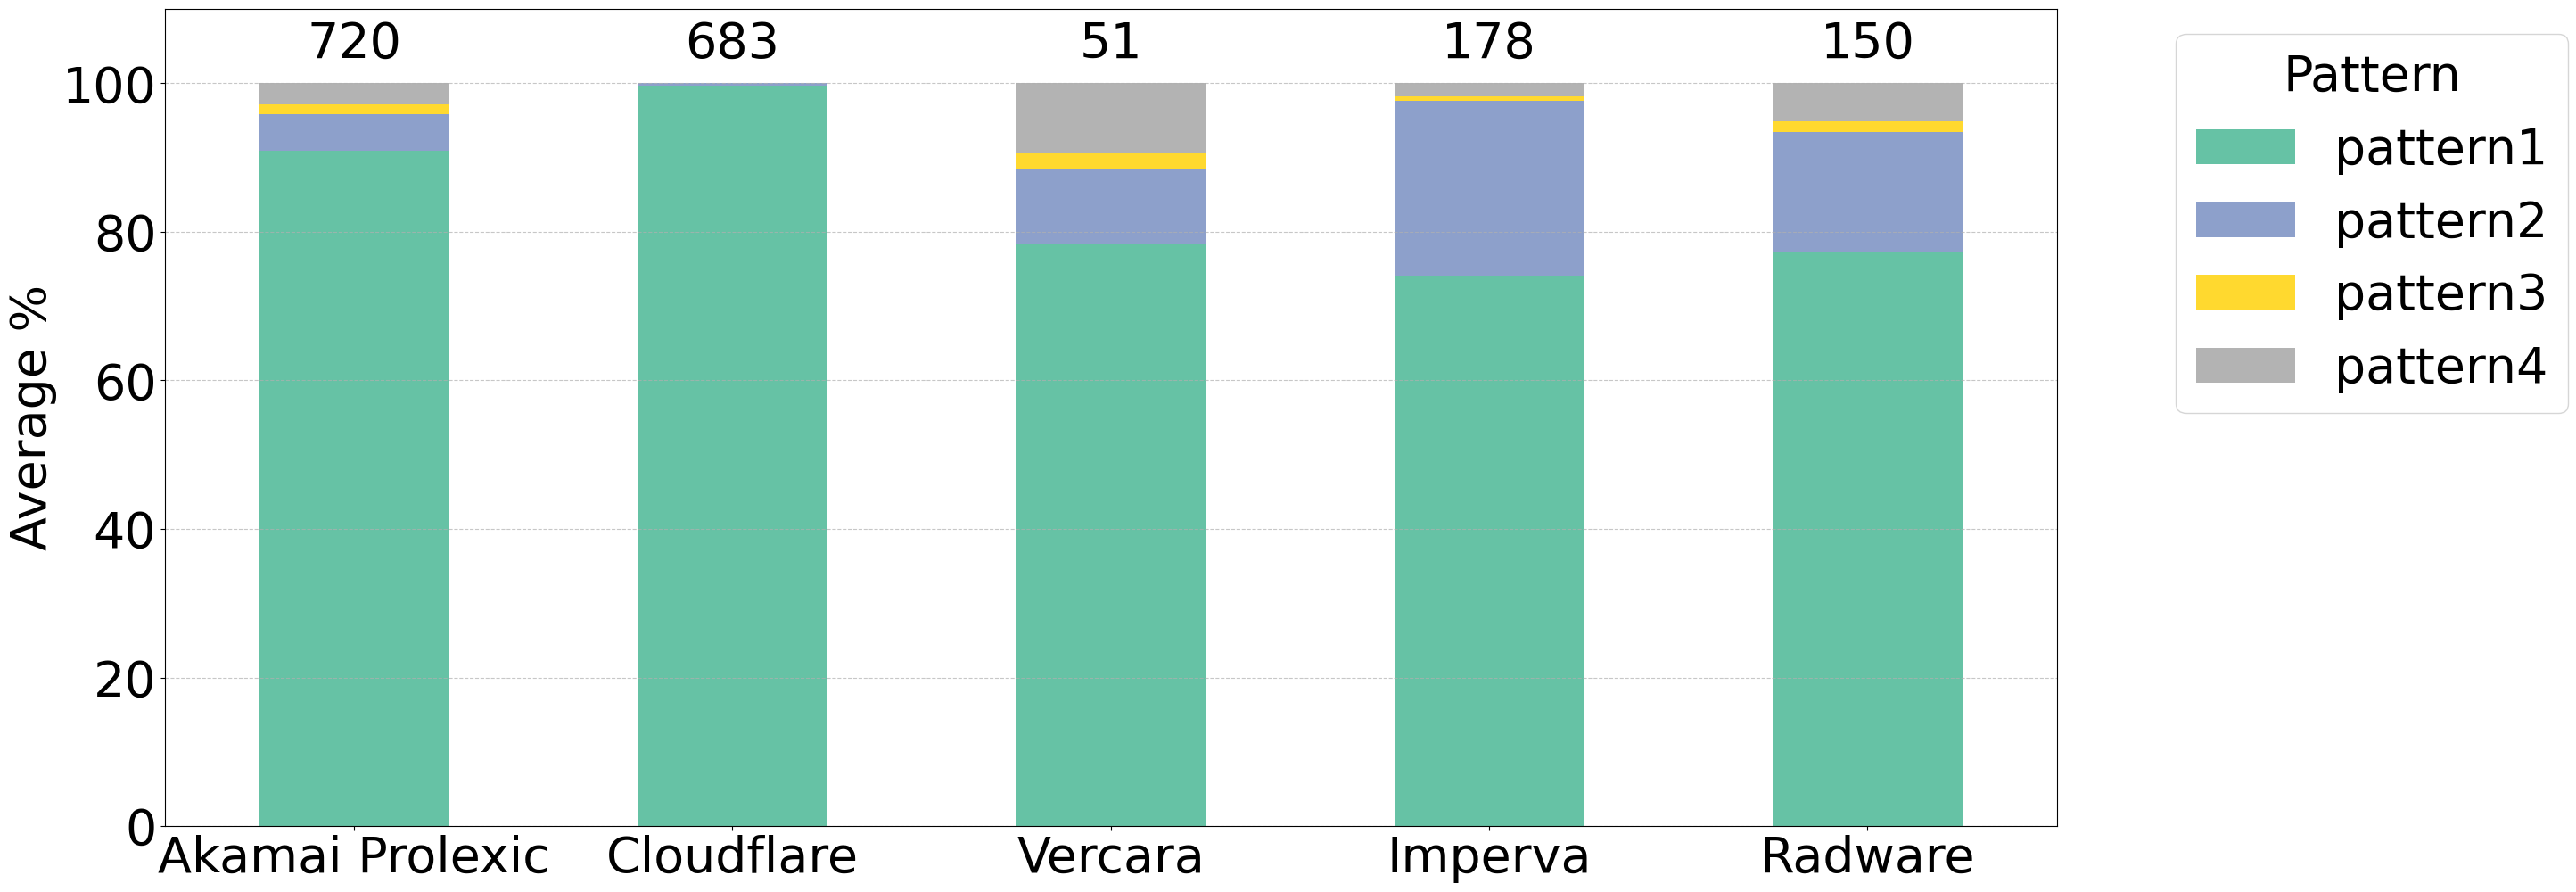

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
# Globally update the font size
plt.rcParams.update({'font.size': 40})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Example data for akamai
akamai = {
    'month': ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
    'pattern1': [643, 642, 648, 649, 650, 656, 658, 663, 663, 660, 665, 658],
    'pattern2': [39, 39, 41, 39, 37, 39, 35, 34, 30, 32, 31, 32],
    'pattern3': [9, 9, 9, 10, 9, 9, 9, 10, 10, 9, 8, 8],
    'pattern4': [19, 20, 20, 19, 18, 20, 21, 21, 19, 21, 24, 26],
}

cloudflare = {
    'month': ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
    'pattern1': [686, 628, 642, 654, 665, 676, 682, 686, 699, 703, 721, 731],
    'pattern2': [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1],
    'pattern3': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'pattern4': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
}

vercara = {
    'month': ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
    'pattern1': [42, 38, 40, 38, 39, 40, 41, 40, 42, 42, 41, 38],
    'pattern2': [5, 5, 5, 5, 5, 6, 5, 5, 5, 6, 5, 5],
    'pattern3': [0, 2, 2, 2, 1, 2, 1, 1, 0, 1, 0, 1],
    'pattern4': [7, 1, 1, 1, 4, 5, 7, 6, 7, 6, 3, 11],
}

imperva = {
    'month': ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
    'pattern1': [135, 133, 133, 127, 130, 133, 125, 130, 133, 129, 134, 138],
    'pattern2': [39, 40, 42, 43, 42, 42, 40, 42, 42, 42, 41, 46],
    'pattern3': [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'pattern4': [4, 5, 4, 3, 2, 3, 3, 3, 2, 3, 2, 3],
}

radware = {
    'month': ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
    'pattern1': [120, 106, 107, 104, 108, 113, 116, 114, 120, 124, 127, 128],
    'pattern2': [22, 26, 25, 25, 26, 23, 24, 19, 22, 23, 28, 25],
    'pattern3': [2, 1, 1, 1, 0, 1, 5, 1, 2, 5, 5, 5],
    'pattern4': [9, 7, 7, 7, 5, 6, 7, 6, 9, 9, 10, 10],
}

# Create a function to compute average percentage pattern distribution
def get_avg_percentage(df):
    df_patterns = df[['pattern1', 'pattern2', 'pattern3', 'pattern4']]
    total = df_patterns.sum(axis=1)
    percent_df = df_patterns.div(total, axis=0) * 100
    return percent_df.mean()


def get_total_average(df):
    total = df[['pattern1', 'pattern2', 'pattern3', 'pattern4']].sum(axis=1)
    return round(total.mean())


# Convert to DataFrame and compute averages
df_akamai = pd.DataFrame(akamai)
avg_akamai = get_avg_percentage(df_akamai)
avg_ases_akamai = get_total_average(df_akamai)

df_cloudflare = pd.DataFrame(cloudflare)
avg_cloudflare = get_avg_percentage(df_cloudflare)
avg_ases_cloudflare = get_total_average(df_cloudflare)

df_vercara = pd.DataFrame(vercara)
avg_vercara = get_avg_percentage(df_vercara)
avg_ases_vercara = get_total_average(df_vercara)

df_imperva = pd.DataFrame(imperva)
avg_imperva = get_avg_percentage(df_imperva)
avg_ases_imperva = get_total_average(df_imperva)

df_radware = pd.DataFrame(radware)
avg_radware = get_avg_percentage(df_radware)
avg_ases_radware = get_total_average(df_radware)

# Combine correctly without transpose (to preserve x-axis order)
avg_df = pd.DataFrame([
    avg_akamai,
    avg_cloudflare,
    avg_vercara,
    avg_imperva,
    avg_radware,
], index=['Akamai Prolexic', 'Cloudflare', 'Vercara', 'Imperva', 'Radware'])

# List of avg_ases values in the same order as avg_df index
avg_ases_values = [avg_ases_akamai, avg_ases_cloudflare, avg_ases_vercara, avg_ases_imperva, avg_ases_radware]

# Plot
ax = avg_df.plot(kind='bar', stacked=True, figsize=(30, 11), colormap='Set2')

# Add avg_ases_vendor at the top of the bars
# We need to calculate the top Y position for each stacked bar
bar_containers = ax.containers # Get the list of BarContainer objects for each pattern

# The total height of each stacked bar is the sum of all patterns for that vendor
# This can be obtained by summing across rows of avg_df
total_bar_heights = avg_df.sum(axis=1)

# Iterate through the bars to place the text
for i, total_height in enumerate(total_bar_heights):
    # Get the x-position for the current bar
    # The x-position of the first bar (pattern1) in the container is usually the correct one
    # ax.patches contains all individual rectangles (bars)
    # We need to find the correct bar for the current vendor (i)
    # The patches are ordered by pattern then by vendor.
    # So, patch for vendor 'i' for the first pattern 'pattern1' is at index 'i'.
    # For a stacked bar, the x-coordinate is the same for all segments
    x_pos = bar_containers[0].patches[i].get_x() + bar_containers[0].patches[i].get_width() / 2

    # Place the text slightly above the total height
    plt.text(x_pos, total_height + 2, f'{avg_ases_values[i]}',
             ha='center', va='bottom', color='black')


# Styling
plt.ylabel('Average %')
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.legend(title='Pattern', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("../images/pattern_distribution.pdf")
plt.show()

In [ ]:
print(df_cloudflare)

In [11]:
# Find number of ASes from protected_ases_<year>.txt file in aruba 
import re
from collections import defaultdict

# Initialize structure
vendor_data_raw = defaultdict(lambda: defaultdict(dict))

# Month order for sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

year = "2024"  # Hardcoded, or you can extract from file or filename

with open("../data/protected_ases_"+year+".txt", "r") as file: # This .txt file was copied from the code in Aruba protected-ases-analysis.py
    lines = file.readlines()

current_month = None
current_final = None

for line in lines:
    # Detect the current month
    month_match = re.match(r"Processing month: (\w+)", line)
    if month_match:
        current_month = month_match.group(1)
        continue

    # Capture the final customer count
    final_match = re.search(r"final (\d+)", line)
    if final_match:
        current_final = int(final_match.group(1))
        continue

    # Match scrubber line and assign final value to scrubber and month
    scrubber_match = re.match(r"Done for scrubber (\d+) in \w+", line)
    if scrubber_match and current_month and current_final is not None:
        scrubber = scrubber_match.group(1)
        vendor_data_raw[scrubber][year][current_month] = current_final

# Final structure with sorted months
vendor_data = {}
for scrubber, years_data in vendor_data_raw.items():
    vendor_data[scrubber] = {}
    for yr, month_dict in years_data.items():
        sorted_vals = [month_dict.get(m, 0) for m in month_order]
        vendor_data[scrubber][yr] = sorted_vals

# Print to verify
import pprint
# pprint.pprint(vendor_data)
print(vendor_data)

{'32787': {'2024': [670, 669, 675, 676, 676, 682, 684, 688, 687, 683, 688, 683]}, '13335': {'2024': [687, 628, 642, 654, 665, 677, 683, 687, 700, 704, 722, 732]}, '19551': {'2024': [149, 147, 147, 143, 146, 149, 141, 148, 150, 148, 153, 157]}, '198949': {'2024': [134, 118, 120, 117, 120, 125, 133, 126, 134, 140, 144, 144]}, '19905': {'2024': [45, 42, 44, 42, 42, 44, 44, 43, 45, 46, 45, 43]}}


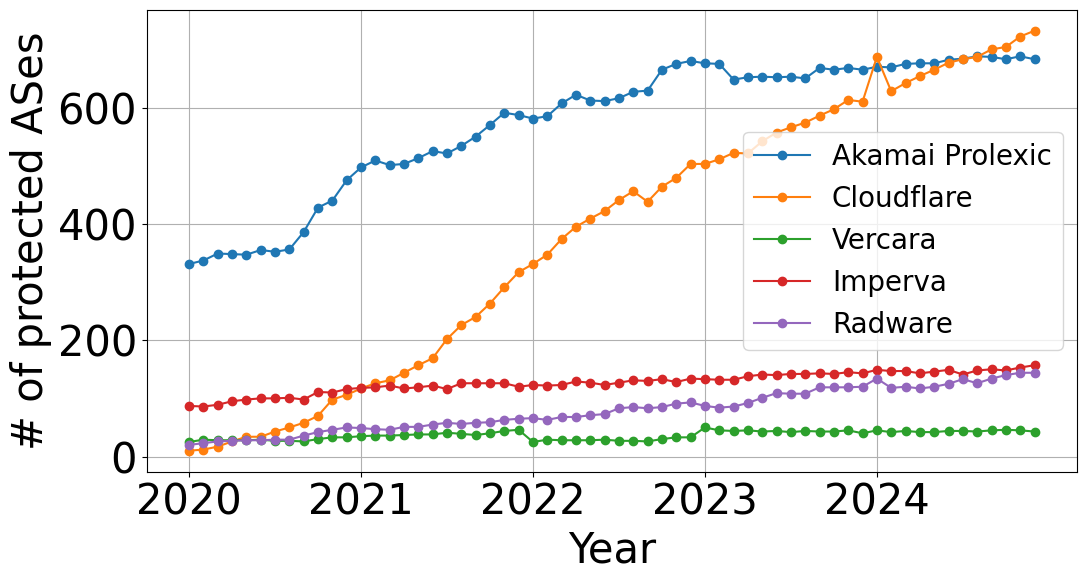

In [54]:
# Copy values from above cell which reads from file named protected_ases_<year>.txt 
# This file is generated from code protected-ases-analysis.py in aruba.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Globally update the font size
plt.rcParams.update({'font.size': 30})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Example data for 5 vendors (replace these with your real data)
vendor_data = {
    "Akamai Prolexic": {
        2020: [331, 337, 349, 348, 347, 355, 352, 356, 386, 428, 440, 475],
        2021: [497, 509, 501, 503, 513, 525, 521, 534, 550, 570, 591, 587],
        2022: [581, 585, 607, 622, 612, 611, 616, 627, 629, 665, 675, 680],
        2023: [676, 675, 648, 652, 653, 652, 653, 650, 668, 665, 668, 665],
        2024: [670, 669, 675, 676, 676, 682, 684, 688, 687, 683, 688, 683],
    },
    "Cloudflare": {
        2020: [10, 12, 17, 26, 34, 34, 43, 50, 58, 70, 98, 106],
        2021: [117, 126, 131, 144, 157, 169, 202, 226, 240, 263, 291, 317],
        2022: [331, 347, 374, 395, 409, 422, 441, 456, 438, 464, 479, 503],
        2023: [503, 511, 522, 521, 542, 557, 566, 574, 586, 597, 613, 610],
        2024: [687, 628, 642, 654, 665, 677, 683, 687, 700, 704, 722, 732],
    },
    "Vercara": { # AS 19905
        2020: [25, 29, 28, 28, 28, 29, 27, 27, 26, 30, 33, 33],
        2021: [35, 36, 36, 37, 38, 38, 41, 39, 37, 40, 44, 46],
        2022: [25, 29, 28, 28, 28, 29, 27, 27, 26, 30, 33, 33],
        2023: [50, 45, 44, 45, 43, 44, 42, 44, 43, 43, 45, 40],
        2024: [45, 42, 44, 42, 42, 44, 44, 43, 45, 46, 45, 43],
    },
    "Imperva": { # AS 19551
        2020: [87, 86, 89, 95, 98, 100, 100, 101, 98, 111, 110, 116],
        2021: [118, 119, 122, 117, 119, 122, 116, 126, 126, 126, 126, 120],
        2022: [123, 122, 123, 129, 127, 123, 127, 131, 130, 133, 128, 134],
        2023: [133, 132, 132, 138, 141, 140, 142, 142, 143, 142, 145, 143],
        2024: [149, 147, 147, 143, 146, 149, 141, 148, 150, 148, 153, 157],
    },
    "Radware": {
        2020: [20, 23, 26, 27, 28, 28, 29, 29, 36, 42, 46, 50],
        2021: [49, 47, 46, 51, 51, 55, 58, 56, 58, 59, 63, 65],
        2022: [66, 63, 68, 68, 71, 73, 83, 85, 83, 85, 91, 93],
        2023: [87, 84, 86, 92, 101, 109, 108, 108, 119, 119, 119, 120],
        2024: [134, 118, 120, 117, 120, 125, 133, 126, 134, 140, 144, 144],
    }
}

plt.figure(figsize=(12, 6))

# Plot each vendor
for vendor, data in vendor_data.items():
    years = []
    values = []
    for year, monthly_values in data.items():
        for month_index in range(12):
            x_val = year + month_index / 12
            years.append(x_val)
            values.append(monthly_values[month_index])
    plt.plot(years, values, marker='o', label=vendor)

# Custom x-ticks: full years only
plt.xticks(list(vendor_data["Akamai Prolexic"].keys()))
plt.xlabel("Year")
plt.ylabel("# of protected ASes")
# plt.title("Monthly Protected AS Trend by Scrubber")
plt.grid(True)
plt.legend(fontsize = 20)
# plt.tight_layout()
plt.savefig("../images/customer_ases.pdf", bbox_inches='tight', pad_inches=0.1)

plt.show()

In [17]:
# Normalize IPV4 normalized by /24.
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from ipaddress import ip_network

year = "2024"
scrubber = "32787"
day = "01"
# Month order for sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

def normalize_prefixes(prefixes, mon, year):
    normalized = set()  # Use a set to avoid duplicates
    for prefix in prefixes:
        network = ip_network(prefix, strict=False)

        if network.version == 4:
            if network.prefixlen < 24:
                normalized.update(map(str, network.subnets(new_prefix=24)))  # Split smaller subnets
            else:
                normalized.add(str(network))
#         elif network.version == 6:
#             normalized.add(str(network))  # Normalize IPv6
    print("Mon %s : %s" %(mon, len(normalized)))
#     print("Total prefixes in %s year %s for AS %s are %s" %(mon, year, scrubber, len(normalized)))
      
# # Example usage
# prefix_list = [
#     "192.168.0.0/23",  # Splits into two /24s
#     "10.0.0.0/20",  # Splits into 16 /24s
#     "2001:db8::/48",
#     "172.16.5.0/25",
# ] 

    
for mon in month_order:
    # Data are in /home/shyam/jupy/ddos_scrubber/data/after_tma/as198949/customers_prefixes_scrubber_198949_01_apr_2020.csv
    df = pd.read_csv("../data/after_tma/as"+scrubber+"/customers_prefixes_scrubber_"+scrubber+"_"+ day + "_" + mon +"_" +year+".csv")
    prefix_list = df["prefix"]
    normalize_prefixes(prefix_list, mon, year)


Mon jan : 41639
Mon feb : 40201
Mon mar : 41046
Mon apr : 39540
Mon may : 39576
Mon jun : 40112
Mon jul : 37741
Mon aug : 38082
Mon sep : 37825
Mon oct : 37118
Mon nov : 37652
Mon dec : 36817


In [ ]:
# Normalize IPV4 normalized by /24 for all the prefixes seen on a day.
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from ipaddress import ip_network

year = "2024"
scrubber = "32787"
day = "01"
# Month order for sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

def normalize_prefixes(prefixes, mon, year):
    normalized = set()  # Use a set to avoid duplicates
    for prefix in prefixes:
        network = ip_network(prefix, strict=False)

        if network.version == 4:
            if network.prefixlen < 24:
                normalized.update(map(str, network.subnets(new_prefix=24)))  # Split smaller subnets
            else:
                normalized.add(str(network))

    print("Mon %s : %s" %(mon, len(normalized)))
#     print("Total prefixes in %s year %s for AS %s are %s" %(mon, year, scrubber, len(normalized)))
      
# # Example usage
# prefix_list = [
#     "192.168.0.0/23",  # Splits into two /24s
#     "10.0.0.0/20",  # Splits into 16 /24s
#     "2001:db8::/48",
#     "172.16.5.0/25",
# ] 

    
for mon in month_order:
    # Data are in /home/shyam/jupy/ddos_scrubber/data/after_tma/as198949/customers_prefixes_scrubber_198949_01_apr_2020.csv
    df = pd.read_csv("../data/after_tma/as"+scrubber+"/customers_prefixes_scrubber_"+scrubber+"_"+ day + "_" + mon +"_" +year+".csv")
    prefix_list = df["prefix"]
    normalize_prefixes(prefix_list, mon, year)

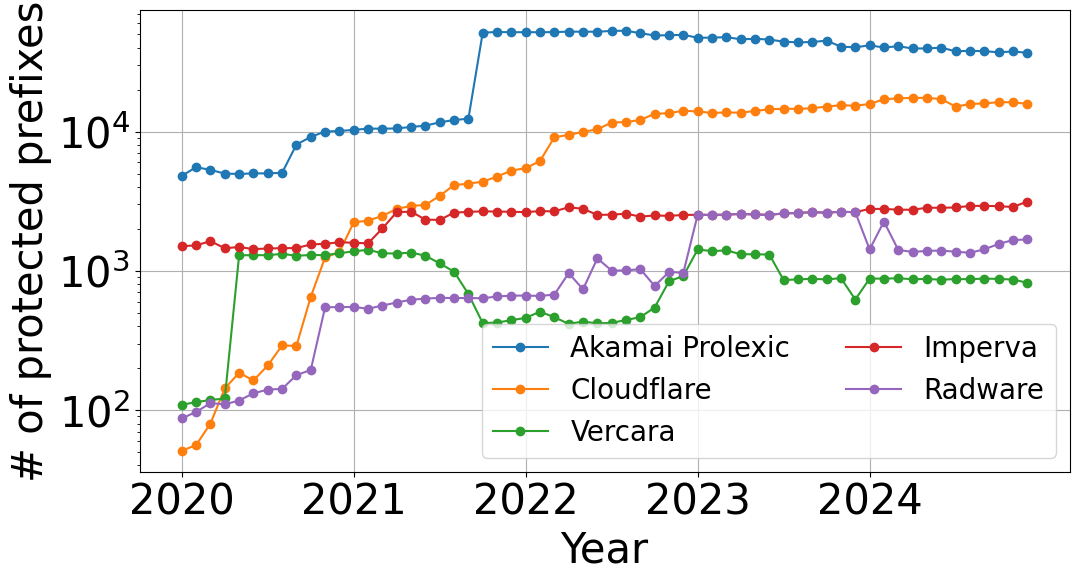

In [47]:
# For IPv4: Copy values from above cell which reads from file named protected_prefixes_<year>.txt 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Globally update the font size
plt.rcParams.update({'font.size': 30})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

vendor_data = {
    "Akamai Prolexic": {
        2020: [4811, 5555, 5306, 4995, 4962, 5010, 5012, 5059, 8065, 9160, 10013, 10106],
        2021: [10284, 10515, 10491, 10538, 10804, 11031, 11663, 12108, 12380, 51395, 51942, 51761],
        2022: [51773, 51748, 51865, 52252, 52204, 52185, 52891, 53052, 50908, 49056, 49245, 49556],
        2023: [47250, 47310, 47706, 46072, 46388, 45862, 44269, 43774, 44014, 45042, 40705, 40347],
        2024: [41639, 40201, 41046, 39540, 39576, 40112, 37741, 38082, 37825, 37118, 37652, 36817],
    },
    "Cloudflare": {
        2020: [51, 56, 80, 143, 185, 163, 209, 291, 289, 650, 1247, 1361],
        2021: [2232, 2293, 2480, 2786, 2925, 2972, 3455, 4134, 4221, 4373, 4748, 5255],
        2022: [5457, 6153, 9113, 9466, 9968, 10391, 11618, 11718, 12123, 13418, 13558, 14139],
        2023: [13952, 13627, 13723, 13679, 14059, 14485, 14580, 14577, 14717, 15140, 15469, 15347],
        2024: [15781, 17070, 17327, 17476, 17472, 17123, 15121, 15781, 15949, 16269, 16240, 15831],
    },
    "Vercara": { # AS 19905
        2020: [109, 114, 118, 121, 1292, 1296, 1294, 1324, 1283, 1299, 1296, 1338],
        2021: [1380, 1415, 1337, 1330, 1352, 1284, 1130, 986, 681, 421, 425, 442],
        2022: [459, 509, 464, 416, 432, 419, 423, 443, 465, 545, 841, 918],
        2023: [1423, 1385, 1402, 1316, 1314, 1309, 858, 868, 876, 867, 886, 622],
        2024: [879, 879, 884, 870, 874, 863, 872, 871, 879, 875, 865, 821],
    },
    "Imperva": { # AS 19551
        2020: [1501, 1524, 1633, 1452, 1483, 1431, 1447, 1454, 1457, 1546, 1564, 1603],
        2021: [1591, 1575, 2016, 2640, 2660, 2332, 2320, 2618, 2651, 2675, 2664, 2656],
        2022: [2640, 2684, 2673, 2861, 2788, 2521, 2532, 2571, 2452, 2497, 2483, 2518],
        2023: [2527, 2522, 2532, 2562, 2539, 2524, 2583, 2603, 2639, 2616, 2656, 2637],
        2024: [2785, 2783, 2748, 2746, 2838, 2839, 2850, 2925, 2928, 2913, 2873, 3145],
    },
    "Radware": { # AS 198949
        2020: [87, 97, 112, 110, 117, 132, 140, 142, 178, 194, 547, 549],
        2021: [550, 534, 563, 592, 620, 631, 640, 637, 638, 635, 654, 663],
        2022: [664, 660, 675, 962, 737, 1228, 1003, 1007, 1028, 778, 981, 967],
        2023: [2527, 2522, 2532, 2562, 2539, 2524, 2583, 2603, 2639, 2616, 2656, 2637],
        2024: [1425, 2258, 1412, 1367, 1390, 1399, 1370, 1349, 1425, 1560, 1662, 1680],
    }
}

plt.figure(figsize=(12, 6))

# Plot each vendor
for vendor, data in vendor_data.items():
    years = []
    values = []
    for year, monthly_values in data.items():
        for month_index in range(12):
            x_val = year + month_index / 12
            years.append(x_val)
            values.append(monthly_values[month_index])
    plt.plot(years, values, marker='o', label=vendor)

# Custom x-ticks: full years only
plt.xticks(list(vendor_data["Akamai Prolexic"].keys()))
plt.xlabel("Year")
plt.ylabel("# of protected prefixes")
plt.yscale('log')  # Set y-axis to logarithmic scale
# plt.title("Monthly Protected Prefix Trend by Scrubber")
plt.grid(True)
plt.legend(ncol=2, fontsize=20)
# plt.tight_layout()
plt.savefig("../images/customer_prefixes_ipv4_normalized.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()



In [45]:
# IPv6
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from ipaddress import ip_network

year = "2024"
scrubber = "19551"
day = "01"
# Month order for sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

def normalize_prefixes(prefixes, mon, year):
    normalized = set()  # Use a set to avoid duplicates
    for prefix in prefixes:
        network = ip_network(prefix, strict=False)

        if network.version == 6:
            normalized.add(str(network))
    print(len(normalized))
    
for mon in month_order:
    # Data are in /home/shyam/jupy/ddos_scrubber/data/after_tma/as198949/customers_prefixes_scrubber_198949_01_apr_2020.csv
    df = pd.read_csv("../data/after_tma/as"+scrubber+"/customers_prefixes_scrubber_"+scrubber+"_"+ day + "_" + mon +"_" +year+".csv")
    prefix_list = df["prefix"]
    normalize_prefixes(prefix_list, mon, year)


134
14
14
14
14
14
14
14
20
18
19
19


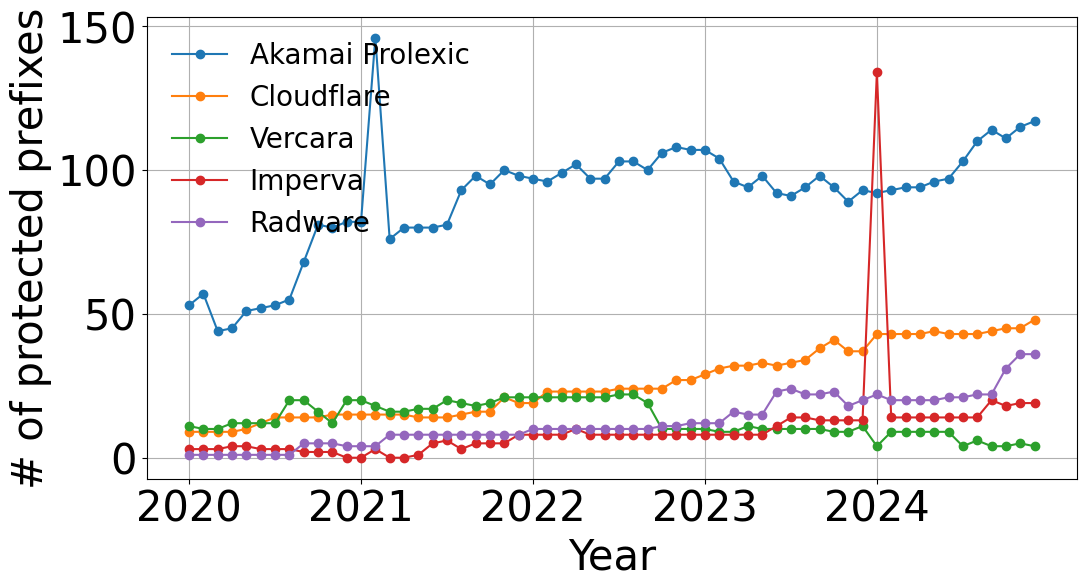

In [56]:
# IPv6: Copy values from above cell which reads from file named protected_prefixes_<year>.txt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Globally update the font size
plt.rcParams.update({'font.size': 30})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Example data for 5 vendors (replace these with your real data)
vendor_data = {
    "Akamai Prolexic": {
        2020: [53, 57, 44, 45, 51, 52, 53, 55, 68, 81, 80, 82],
        2021: [82, 146, 76, 80, 80, 80, 81, 93, 98, 95, 100, 98],
        2022: [97, 96, 99, 102, 97, 97, 103, 103, 100, 106, 108, 107],
        2023: [107, 104, 96, 94, 98, 92, 91, 94, 98, 94, 89, 93],
        2024: [92, 93, 94, 94, 96, 97, 103, 110, 114, 111, 115, 117],
    },
    "Cloudflare": {
        2020: [9, 9, 9, 9, 10, 12, 14, 14, 14, 14, 15, 15],
        2021: [15, 15, 15, 15, 14, 14, 14, 15, 16, 16, 21, 19],
        2022: [19, 23, 23, 23, 23, 23, 24, 24, 24, 24, 27, 27],
        2023: [29, 31, 32, 32, 33, 32, 33, 34, 38, 41, 37, 37],
        2024: [43, 43, 43, 43, 44, 43, 43, 43, 44, 45, 45, 48],
    },
    "Vercara": { # AS 19905
        2020: [11, 10, 10, 12, 12, 12, 12, 20, 20, 16, 12, 20],
        2021: [20, 18, 16, 16, 17, 17, 20, 19, 18, 19, 21, 21],
        2022: [21, 21, 21, 21, 21, 21, 22, 22, 19, 10, 10, 10],
        2023: [10, 9, 9, 11, 10, 10, 10, 10, 10, 9, 9, 11],
        2024: [4, 9, 9, 9, 9, 9, 4, 6, 4, 4, 5, 4],
    },
    "Imperva": { # AS 19551
        2020: [3, 3, 3, 4, 4, 3, 3, 3, 2, 2, 2, 0],
        2021: [0, 3, 0, 0, 1, 5, 6, 3, 5, 5, 5, 8],
        2022: [8, 8, 8, 10, 8, 8, 8, 8, 8, 8, 8, 8],
        2023: [8, 8, 8, 8, 8, 11, 14, 14, 13, 13, 13, 13],
        2024: [134, 14, 14, 14, 14, 14, 14, 14, 20, 18, 19, 19],
    },
    "Radware": { # AS 198949
        2020: [1, 1, 1, 1, 1, 1, 1, 1, 5, 5, 5, 4],
        2021: [4, 4, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
        2022: [10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 12],
        2023: [12, 12, 16, 15, 15, 23, 24, 22, 22, 23, 18, 20],
        2024: [22, 20, 20, 20, 20, 21, 21, 22, 22, 31, 36, 36],
    }
}

plt.figure(figsize=(12, 6))

# Plot each vendor
for vendor, data in vendor_data.items():
    years = []
    values = []
    for year, monthly_values in data.items():
        for month_index in range(12):
            x_val = year + month_index / 12
            years.append(x_val)
            values.append(monthly_values[month_index])
    plt.plot(years, values, marker='o', label=vendor)

# Custom x-ticks: full years only
plt.xticks(list(vendor_data["Akamai Prolexic"].keys()))
plt.xlabel("Year")
plt.ylabel("# of protected prefixes")
# plt.yscale('log')  # Set y-axis to logarithmic scale
# plt.title("Monthly Protected Prefix Trend by Scrubber")
plt.grid(True)
plt.legend(fontsize=20, frameon=False)
# plt.tight_layout()
plt.savefig("../images/customer_prefixes_ipv6.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()



In [46]:
# count_protected_prefixes_all.py
# Count the number of protected prefixes of all scrubbers (IPv4 and Ipv6) 
# Sum the prefix values of all 5 vendors for each month, from January to December for each year from 2020 to 2024.
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from ipaddress import ip_network

year = "2020"
scrubber = "198949"
day = "01"
# Month order for sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

for mon in month_order:
    # Data are in /home/shyam/jupy/ddos_scrubber/data/after_tma/as198949/customers_prefixes_scrubber_198949_01_apr_2020.csv
    df = pd.read_csv("../data/after_tma/as"+scrubber+"/customers_prefixes_scrubber_"+scrubber+"_"+ day + "_" + mon +"_" +year+".csv")
    prefixes = df["prefix"].unique()
    print("%s" %(len(prefixes)))

data = {    
"Akamai Prolexic": {
        2020: [2096, 2283, 2306, 2214, 2200, 2256, 2251, 2295, 2482, 2776, 2891, 3085],
        2021: [3158, 3378, 3251, 3301, 3366, 3454, 3651, 3835, 3961, 4133, 4297, 4305],
        2022: [4269, 4283, 4375, 4604, 4663, 4700, 4958, 4868, 4874, 5023, 4947, 4947],
        2023: [4946, 4965, 4920, 4903, 5077, 5046, 5192, 5204, 5244, 5608, 5444, 5372],
        2024: [5400, 5348, 5384, 5402, 5426, 5716, 5857, 5761, 5796, 5887, 6024, 6018],
    },
    "Cloudflare": {
        2020: [37, 41, 59, 68, 86, 90, 128, 163, 176, 249, 400, 495],
        2021: [591, 631, 614, 646, 753, 749, 863, 973, 1024, 1100, 1270, 1342],
        2022: [1366, 1468, 1600, 1719, 2045, 2095, 2230, 2287, 2009, 2174, 2253, 2368],
        2023: [2331, 2353, 2435, 2472, 2553, 2661, 2713, 2729, 2741, 2801, 2952, 2855],
        2024: [3487, 3028, 3134, 3152, 3242, 3295, 3358, 3487, 3687, 3718, 3724, 3642],
    },
    "Vercara": { # AS 19905
        2020: [113, 117, 123, 128, 238, 307, 305, 343, 321, 331, 321, 373],
        2021: [435, 464, 621, 621, 634, 616, 557, 438, 396, 430, 436, 452],
        2022: [466, 516, 470, 421, 429, 424, 429, 449, 476, 486, 538, 520],
        2023: [545, 512, 529, 501, 498, 493, 379, 389, 397, 387, 405, 384],
        2024: [394, 399, 404, 390, 394, 383, 387, 388, 394, 390, 381, 336],
    },
    "Imperva": { # AS 19551
        2020: [820, 845, 956, 774, 772, 725, 741, 748, 754, 843, 861, 898],
        2021: [886, 873, 756, 793, 813, 774, 765, 807, 838, 862, 852, 849],
        2022: [833, 876, 867, 1048, 986, 971, 983, 1016, 900, 932, 932, 974],
        2023: [981, 971, 982, 997, 999, 983, 1031, 1046, 1074, 1051, 1077, 1085],
        2024: [1342, 1118, 1110, 1103, 1181, 1193, 1198, 1283, 1299, 1295, 1238, 1255],
    },
    "Radware": { # AS 198949
        2020: [88, 98, 107, 111, 118, 128, 136, 137, 177, 191, 230, 235],
        2021: [236, 220, 239, 266, 268, 279, 287, 285, 286, 283, 303, 312],
        2022: [316, 313, 327, 362, 393, 382, 416, 420, 428, 423, 583, 585],
        2023: [560, 552, 564, 638, 677, 735, 829, 870, 918, 928, 902, 976],
        2024: [944, 963, 943, 903, 926, 932, 917, 889, 944, 1060, 1097, 1126],
    }
}


88
98
107
111
118
128
136
137
177
191
230
235


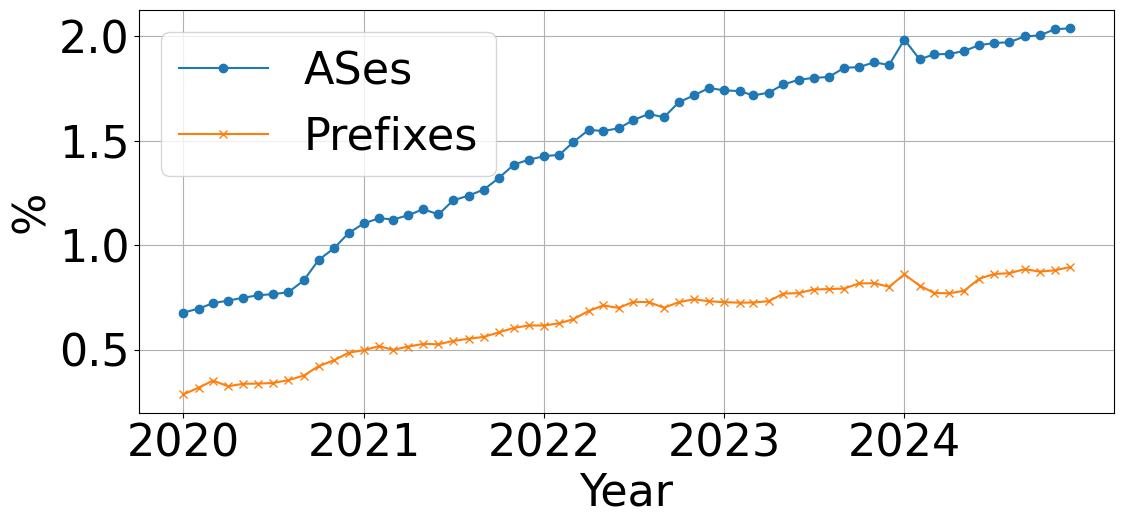

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Globally update the font size
plt.rcParams.update({'font.size': 32})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Replace with your actual data
date_range = pd.date_range(start='2020-01-01', end='2024-12-01', freq='MS')
data = {
    'date': date_range,
    'number_of_customer_ases': [
                                464, 479, 501, 511, 523, 535, 540, 550, 593, 666, 709, 764,
                                801, 822, 820, 838, 863, 894, 923, 969, 996, 1042, 1097, 1116,
                                1133, 1144, 1193, 1241, 1242, 1253, 1291, 1324, 1309, 1370, 1398, 1432,
                                1424, 1423, 1411, 1421, 1454, 1476, 1485, 1492, 1534, 1539, 1560, 1551,
                                1656, 1579, 1602, 1606, 1623, 1651, 1658, 1665, 1689, 1696, 1723, 1730
                            ], # File is in data/after_tma/customers_ases_scrubber_all_01_<mon>_<year>.csv
    'number_of_total_ases': [
                                68445, 68740, 69298, 69478, 69859, 70297, 70492, 70915, 71293, 71629, 71971, 72141,
                                72504, 72741, 72998, 73226, 73586, 77875, 75942, 78272, 78617, 78840, 79124, 79160,
                                79421, 79829, 79843, 79969, 80252, 80334, 80702, 81282, 81149, 81305, 81365, 81675,
                                81762, 81852, 82155, 82099, 82143, 82344, 82432, 82622, 82929, 83050, 83150, 83250,
                                83433, 83536, 83693, 83821, 84087, 84298, 84242, 84401, 84453, 84595, 84701, 84851
                            ],

    # Data from final_ases_prefixes_2017_2024.xlsx
    'number_of_customer_prefixes': [
                                    3153, 3383, 3550, 3292, 3411, 3503, 3559, 3682, 3903, 4384, 4698, 5082,
                                     5301, 5551, 5480, 5626, 5832, 5868, 6118, 6336, 6504, 6805, 7152, 7256,7245,
                                     7452, 7630, 8146, 8510, 8567, 9013, 9030, 8682, 9029, 9244, 9385, 9353,
                                     9344, 9422, 9502, 9796, 9910, 10136, 10230, 10365, 10760, 10769, 10662, 
                                     11532, 10849, 10968, 10942, 11160, 11511, 11708, 11796, 12106, 12337, 
                                     12448, 12362],# protected-prefixes-analysis.ipynb.
    'number_of_total_prefixes': [
                                    1102097, 1062579, 1007418, 1012405, 1012077, 1036429, 1044012, 1038578, 1037816, 
                                    1040454, 1045897, 1046533, 1064334, 1072668, 1097586, 1091434, 1105010, 1115104, 
                                    1127948, 1146814, 1157778, 1167331, 1182910, 1177475, 1176385, 1188663, 1181522, 
                                    1188145, 1195249, 1223089, 1235541, 1240298, 1237931, 1240971, 1246195, 1282345,
                                    1284740, 1288427, 1297623, 1297530, 1274223, 1285079, 1285707, 1294250, 1307363, 
                                    1316268, 1315754, 1330389, 1340176, 1344360, 1420601, 1420511, 1426565, 1370046, 
                                    1357503, 1361123, 1366996, 1411274, 1414099, 1380505
                                ]

        # Data from final_ases_prefixes_2017_2024.xlsx

        }

# Create DataFrame
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

# Calculate percentages
df['protected_ases_pct'] = (df['number_of_customer_ases'] / df['number_of_total_ases']) * 100
df['protected_prefixes_pct'] = (df['number_of_customer_prefixes'] / df['number_of_total_prefixes']) * 100

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['protected_ases_pct'], label='ASes', marker='o', markersize=6)
plt.plot(df['date'], df['protected_prefixes_pct'], label='Prefixes', marker='x', markersize=6)

# Show only year labels on x-axis
years = pd.date_range(start='2020-01-01', end='2024-12-01', freq='YS')  # Year Start
plt.xticks(years, years.year)

# Formatting
# plt.title('Monthly % of Protected ASes and Prefixes')
plt.xlabel('Year')
plt.ylabel('%')
# plt.yticks(fontsize = 22)
# plt.xticks(fontsize=22)
# plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../images/merged_aggregate_customer_ases_percentages_ases.pdf")
plt.show()


In [8]:
# Count the total number of ASes per year that are stored in CSV file. The values are used by the plot above.
import glob
import re
import pandas as pd

year = "2020"
# Define the base path and file pattern
file_pattern = "../data/after_tma/customers_ases_scrubber_all_01_*.csv"

# Month order for sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Get all matching files
all_files = glob.glob(file_pattern)

# Extract and sort by month
def get_month_index(file):
    match = re.search(r'01_([a-z]{3})_'+year+'\.csv$', file)
    if match:
        month = match.group(1)
        return month_order.index(month)
    return -1  # If not matched, put it at the start

# Filter and sort
valid_files = [f for f in all_files if re.search(r'01_[a-z]{3}_'+year+'\.csv$', f)]
valid_files.sort(key=get_month_index)

# Get row counts
row_counts = []

for file in valid_files:
    try:
        df = pd.read_csv(file)
        row_counts.append(len(df))
    except Exception as e:
        print(f"Error reading {file}: {e}")
        row_counts.append(None)

# Output
print("Row counts (starting with January):")
print(row_counts)


Row counts (starting with January):
[464, 479, 501, 511, 523, 535, 540, 550, 593, 666, 709, 764]


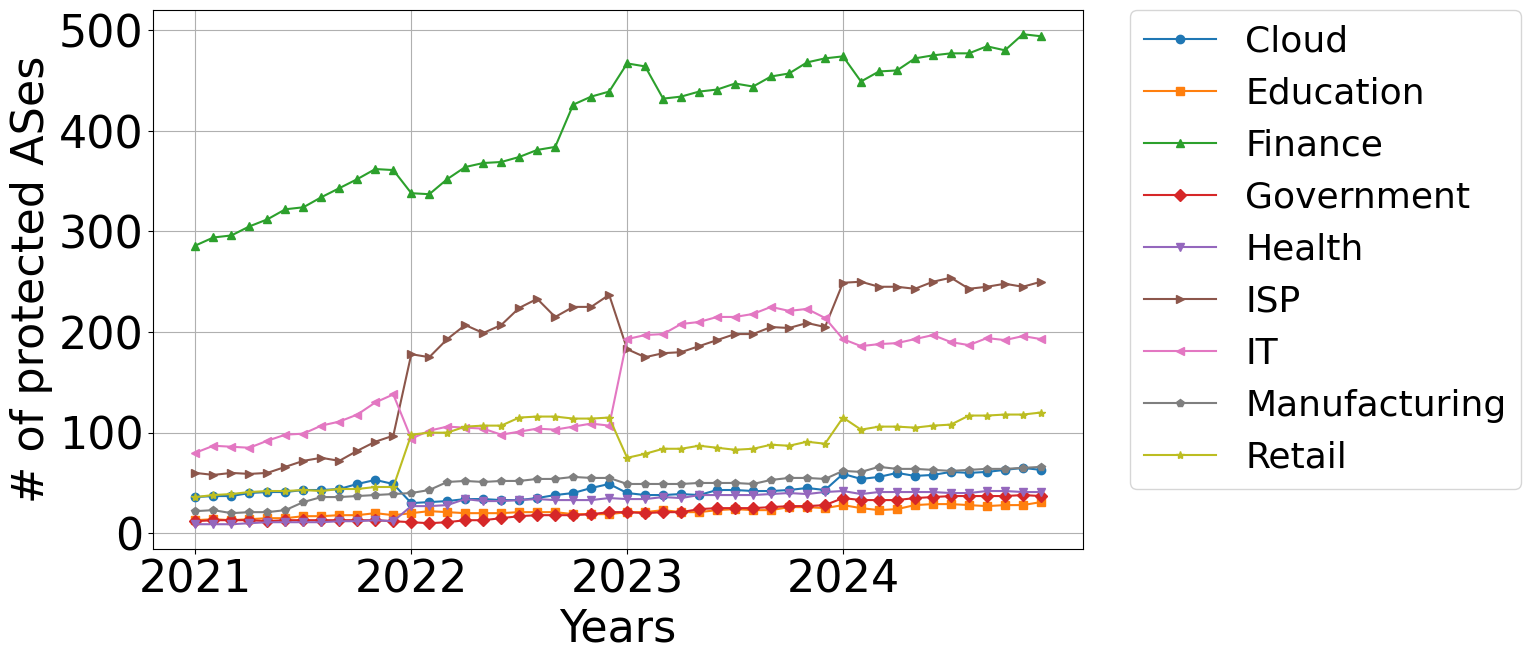

In [132]:
# Plot of total values of each categories for all the five scrubbers
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
# Globally update the font size
plt.rcParams.update({'font.size': 32})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Read data from csv files: /data/after_tma/final_confirmed_customer_ases_categories_counts_01_<mon>_<year>.csv
# Categories: "Cloud", "Education", "Finance", "Government", "Health", "ISP", "IT", "Manufacturing", "Retail"

category_data = {
    "Cloud": {
        2021: [36, 37, 37, 40, 41, 41, 43, 43, 44, 49, 53, 49], 
        2022: [30, 31, 32, 34, 34, 33, 33, 35, 38, 40, 45, 49], 
        2023: [40, 38, 38, 39, 38, 43, 43, 42, 42, 43, 45, 43], 
        2024: [59, 54, 56, 60, 57, 58, 61, 60, 61, 63, 65, 63]
    },
    "Education": {
        2021: [13, 14, 13, 14, 15, 15, 17, 17, 18, 18, 20, 18],
        2022: [20, 22, 21, 20, 20, 20, 21, 21, 21, 19, 19, 19], 
        2023: [21, 21, 23, 21, 21, 23, 24, 23, 23, 26, 26, 25], 
        2024: [28, 25, 23, 24, 28, 29, 29, 28, 27, 28, 28, 31]
    },    
    "Finance": {
        2021: [286, 294, 296, 305, 312, 322, 324, 334, 343, 352, 362, 361], 
        2022: [338, 337, 352, 364, 368, 369, 374, 381, 384, 426, 434, 439], 
        2023: [467, 464, 432, 434, 439, 441, 447, 444, 454, 457, 468, 472], 
        2024: [474, 449, 459, 460, 472, 475, 477, 477, 484, 480, 496, 494],
    },
    "Government": {
        2021: [12, 13, 13, 13, 12, 13, 13, 13, 13, 13, 13, 12], 
        2022: [11, 10, 11, 13, 13, 15, 17, 18, 18, 18, 19, 21], 
        2023: [21, 20, 21, 21, 24, 25, 25, 25, 26, 27, 27, 28], 
        2024: [35, 33, 33, 33, 35, 36, 37, 37, 37, 37, 38, 37]
    },

    "Health": {
        2021: [9, 9, 9, 10, 11, 11, 11, 11, 12, 12, 13, 12], 
        2022: [27, 27, 28, 34, 32, 32, 33, 34, 33, 33, 33, 35], 
        2023: [34, 34, 36, 35, 38, 38, 38, 38, 39, 40, 39, 41], 
        2024: [42, 39, 41, 41, 41, 41, 40, 40, 42, 42, 41, 41]
    },
    "ISP": {
        2021: [60, 58, 60, 59, 60, 66, 72, 75, 72, 82, 91, 97], 
        2022: [178, 175, 193, 207, 199, 207, 224, 233, 215, 225, 225, 237], 
        2023: [183, 175, 179, 180, 186, 192, 198, 198, 205, 204, 209, 205], 
        2024: [249, 250, 245, 245, 243, 250, 254, 243, 245, 248, 245, 250]
    },
    "IT": {
        2021: [80, 87, 86, 85, 92, 98, 99, 107, 111, 118, 130, 138], 
        2022: [94, 102, 106, 105, 104, 98, 101, 104, 103, 106, 109, 107], 
        2023: [193, 197, 198, 208, 210, 215, 215, 218, 225, 221, 223, 214], 
        2024: [193, 186, 188, 189, 193, 197, 190, 187, 194, 192, 196, 193]
    },
    "Manufacturing": {
        2021: [22, 23, 20, 21, 21, 23, 31, 36, 36, 37, 38, 39], 
        2022: [40, 43, 51, 52, 51, 52, 52, 54, 54, 56, 55, 55], 
        2023: [49, 49, 49, 49, 50, 50, 50, 49, 53, 55, 55, 54], 
        2024: [62, 61, 66, 64, 64, 63, 62, 63, 64, 64, 65, 66]
    },
    "Retail": {
        2021: [36, 38, 39, 41, 42, 42, 43, 42, 44, 44, 46, 46], 
        2022: [98, 100, 100, 106, 107, 107, 115, 116, 116, 114, 114, 115], 
        2023: [75, 79, 84, 84, 87, 85, 83, 84, 88, 87, 91, 89], 
        2024: [115, 103, 106, 106, 105, 107, 108, 117, 117, 118, 118, 120]
    }
}
    
plt.figure(figsize=(12, 7))

# Define distinct markers for each category
markers = ["o", "s", "^", "D", "v", ">", "<", "p", "*"]

categories = list(category_data.keys())

# Plot each vendor with a unique marker
for i, (vendor, data) in enumerate(category_data.items()):
    marker = markers[i % len(markers)]
    years = []
    values = []
    for year, monthly_values in data.items():
        for month_index in range(12):
            x_val = year + month_index / 12
            years.append(x_val)
            values.append(monthly_values[month_index])
    plt.plot(years, values, marker=marker, label=vendor)

# Custom x-ticks: full years only
plt.xticks(list(category_data["Cloud"].keys()))
plt.yticks()
plt.xlabel("Years")
plt.ylabel("# of protected ASes")
plt.grid(True)
plt.legend(fontsize = 26, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig("/home/shyam/jupy/ddos_scrubber/images/aggregate_customer_types.pdf", bbox_inches='tight')
plt.show()

In [10]:
values

[36,
 38,
 39,
 41,
 42,
 42,
 43,
 42,
 44,
 44,
 46,
 46,
 98,
 100,
 100,
 106,
 107,
 107,
 115,
 116,
 116,
 114,
 114,
 115,
 75,
 79,
 84,
 84,
 87,
 85,
 83,
 84,
 88,
 87,
 91,
 89,
 115,
 103,
 106,
 106,
 105,
 107,
 108,
 117,
 117,
 118,
 118,
 120]

In [40]:
# Count number of ASes in each categories from csv files
import os
import pandas as pd

# Path to your CSV directory
folder = "../data/after_tma/"
day = "01"

category_name = "Retail Stores, Wholesale, and E-commerce Sites"
category_short_name = "Retail"

# Months in order to preserve sequence
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Years you're interested in
years = [2021, 2022, 2023, 2024]

# Initialize result dict
cloud_dict = {category_short_name: {}}

for year in years:
    cloud_counts = []

    for mon in month_order:
        filename = f"final_confirmed_customer_ases_categories_counts_{day}_{mon}_{year}.csv"
        filepath = os.path.join(folder, filename)

        try:
            df = pd.read_csv(filepath)

            # Normalize cdata = {    
ategory column to lowercase for matching
#             df['Category'] = df['Category'].str.strip().str.lower()

            # Find cloud row (either in Layer 1 or Layer 2)
            cloud_row = df[df['Category'] == category_name]

            if not cloud_row.empty:
                count = int(cloud_row['ASN Count'].values[0])
            else:
                count = 0  # Assume 0 if no cloud category found that month

            cloud_counts.append(count)

        except FileNotFoundError:
            print(f"Missing: {filename}")
            cloud_counts.append(0)  # Optionally 0 for missing file
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            cloud_counts.append(0)

    cloud_dict[category_short_name][year] = cloud_counts

# Final result
print(cloud_dict)


{'Retail': {2021: [36, 38, 39, 41, 42, 42, 43, 42, 44, 44, 46, 46], 2022: [98, 100, 100, 106, 107, 107, 115, 116, 116, 114, 114, 115], 2023: [75, 79, 84, 84, 87, 85, 83, 84, 88, 87, 91, 89], 2024: [115, 103, 106, 106, 105, 107, 108, 117, 117, 118, 118, 120]}}


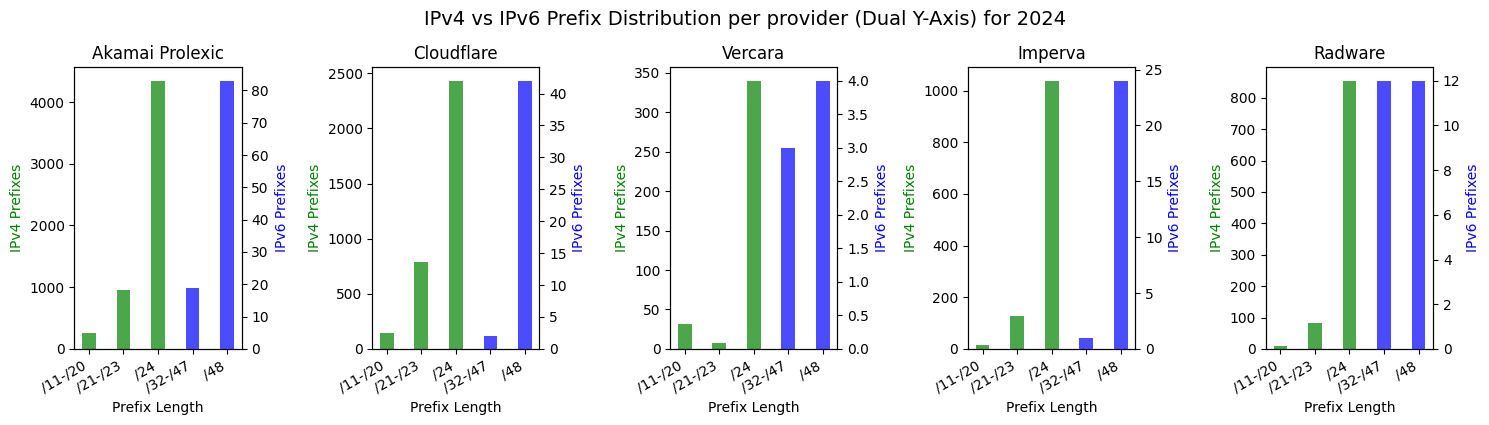

In [144]:
# After TMA
# Prefix characterisitcs (prefix length of five scrubbers)
import matplotlib.pyplot as plt
import numpy as np

# Define providers
providers = ["Akamai Prolexic", "Cloudflare", "Vercara", "Imperva", "Radware"]

# Define prefix lengths
ipv4_prefixes = ["/11-/20", "/21-/23", "/24"]
ipv6_prefixes = ["/32-/47", "/48"]

# Sample Data: Replace with actual counts
ipv4_data = {
    "Akamai Prolexic": [258, 962, 4345], 
    "Cloudflare": [141, 789, 2432],
    "Vercara": [32, 8, 340],
    "Imperva": [15, 127, 1038],
    "Radware": [9, 83, 854]
}

ipv6_data = {
    "Akamai Prolexic": [19, 83],
    "Cloudflare": [2, 42],
    "Vercara": [3, 4],
    "Imperva": [1, 24],
    "Radware": [12, 12]
}

# Create figure with subplots
fig, axes = plt.subplots(1, len(providers), figsize=(15, 4), sharey=False)

for i, provider in enumerate(providers):
    ax = axes[i]
    ax2 = ax.twinx()  # Create secondary y-axis for IPv6
    
    x_ipv4 = np.arange(len(ipv4_prefixes))  # X positions for IPv4
    x_ipv6 = np.arange(len(ipv6_prefixes)) + len(ipv4_prefixes)  # Shift IPv6 x positions

    width = 0.4  # Bar width
    
    # IPv4 Bars (Left Y-Axis)
    ax.bar(x_ipv4, ipv4_data[provider], width=width, color='green', label="IPv4", alpha=0.7)
    ax.set_ylabel("IPv4 Prefixes", color="green")
    
    # IPv6 Bars (Right Y-Axis)
    ax2.bar(x_ipv6, ipv6_data[provider], width=width, color='blue', label="IPv6", alpha=0.7)
    ax2.set_ylabel("IPv6 Prefixes", color="blue")
    
    ax.set_title(provider)
    
    # Combine x-ticks for both IPv4 and IPv6
    all_xticks = list(x_ipv4) + list(x_ipv6)
    all_labels = ipv4_prefixes + ipv6_prefixes
    
    ax.set_xticks(all_xticks)
    ax.set_xticklabels(all_labels, rotation=30, ha="right")
    ax.set_xlabel("Prefix Length")

# Adjust layout
plt.tight_layout()
plt.suptitle("IPv4 vs IPv6 Prefix Distribution per provider (Dual Y-Axis) for 2024", fontsize=14, y=1.05)
plt.savefig("../images/prefix_characteristics.pdf")

plt.show()


In [32]:
# Find prefix lengths of from prefix csv files.
import pandas as pd
import ipaddress
from collections import defaultdict
import glob

scrubber = "198949"
year = "2024"

# Path to your 12 CSV files
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']


file_list = sorted(glob.glob("../data/after_tma/as"+scrubber+"/customers_prefixes_scrubber_"+scrubber+"_*"+year+".csv"))  # Change "data/*.csv" to match your file path

# Group definitions
ipv4_groups = {
    "11-20": range(11, 21),
    "21-23": range(21, 24),
    "24": [24],
}

ipv6_groups = {
    "32-47": range(32, 48),
    "48": [48],
}

# Track totals for each group
ipv4_group_totals = defaultdict(int)
ipv6_group_totals = defaultdict(int)

# Loop through files
for file in file_list:
    df = pd.read_csv(file)
    prefixes = df['prefix']  # Adjust column name if needed

    ipv4_counts = defaultdict(int)
    ipv6_counts = defaultdict(int)

    for p in prefixes:
        try:
            net = ipaddress.ip_network(p, strict=False)
            if isinstance(net, ipaddress.IPv4Network):
                ipv4_counts[net.prefixlen] += 1
            elif isinstance(net, ipaddress.IPv6Network):
                ipv6_counts[net.prefixlen] += 1
        except ValueError:
            continue  # Skip invalid prefixes

    # Aggregate into defined groups
    for group, lengths in ipv4_groups.items():
        ipv4_group_totals[group] += sum(ipv4_counts[l] for l in lengths)

    for group, lengths in ipv6_groups.items():
        ipv6_group_totals[group] += sum(ipv6_counts[l] for l in lengths)

# Calculate averages
num_months = len(file_list)

print("Average IPv4 Prefixes per Month:")
for group in ipv4_groups:
    avg = ipv4_group_totals[group] / num_months
#     print(f"{group}: {avg:.2f}")
    print(f"{group}: {round(avg)}")

print("\nAverage IPv6 Prefixes per Month:")
for group in ipv6_groups:
    avg = ipv6_group_totals[group] / num_months
    print(f"{group}: {round(avg)}")



Average IPv4 Prefixes per Month:
11-20: 9
21-23: 83
24: 854

Average IPv6 Prefixes per Month:
32-47: 12
48: 12


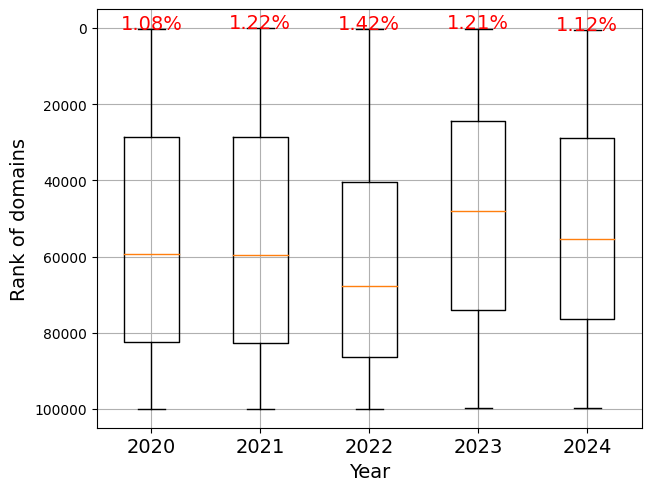

In [168]:
# Using Alexa 100k only 
# TMA extended work

import matplotlib.pyplot as plt
import pandas as pd

# Globally update the font size

years = ["2020", "2021", "2022", "2023", "2024"]
# years = ["2020", "2021", "2022"]

data_dict = {}

for year in years:
    # For rest of the years, we use Alexa 1M list
    if year in ["2020", "2021", "2022"]:
        df = pd.read_csv("../data/after_tma/openintel_alexa_ip_domains_ranks_100k_01_jan_"+year+".csv")
    else:
        df = pd.read_csv("../data/after_tma/openintel_tranco_ip_domains_ranks_100k_01_jan_"+year+".csv")
    ranks = df["rank"].unique()
    data_dict[year] = ranks

fig, ax = plt.subplots(layout='constrained') # layout='constrained' is added because x-label was cut off before.
ax.boxplot(data_dict.values())

# Annotate with the number of samples
for i, (key, values) in enumerate(data_dict.items(), start=1):
    year = key
    
    no_of_total_domains = 100000
        
    percentage_domain = len(values)*100/no_of_total_domains
    percentage_domain = round(percentage_domain, 2)
    ax.text(i, min(values), f"{percentage_domain}%", ha='center', fontsize=14, color="red")

# Set x-axis labels
ax.set_xticklabels(data_dict.keys(), fontsize=14)

ax.set_xticklabels(data_dict.keys())
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Rank of domains", fontsize=14)
# Invert y-axis so that lower ranks are at the top
ax.invert_yaxis()
# Start from rank 1 (not 0)
ax.grid()

# fig.suptitle("Alexa for 2020 to 2022", fontsize = 14)
fig.savefig("../images/correlating_alexa_tranco_100K.pdf")

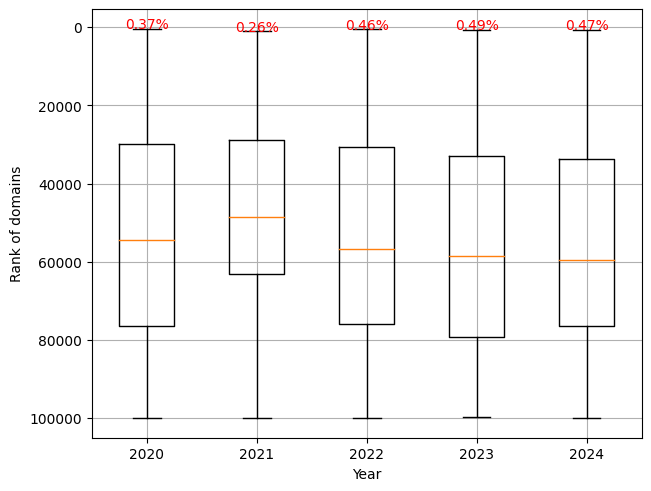

In [227]:
# Using Umbrella 100k only 
# TMA extended work

import matplotlib.pyplot as plt
import pandas as pd

# years = ["jan_2020", "jun_2020","jan_2021", "jun_2021", "jan_2022"]
years = ["2020", "2021", "2022", "2023", "2024"]

data_dict = {}

for year in years:
    # For rest of the years, we use umbrella 1M list
    df = pd.read_csv("../data/after_tma/openintel_umbrella_ip_domains_ranks_100k_01_jan_"+year+".csv")
    ranks = df["rank"].unique()
    data_dict[year] = ranks



fig, ax = plt.subplots(layout='constrained') # layout='constrained' is added because x-label was cut off before.
ax.boxplot(data_dict.values())

# Annotate with the number of samples
for i, (key, values) in enumerate(data_dict.items(), start=1):
    year = key
    
    no_of_total_domains = 100000
        
    percentage_domain = len(values)*100/no_of_total_domains
    percentage_domain = round(percentage_domain, 2)
    ax.text(i, min(values), f"{percentage_domain}%", ha='center', fontsize=10, color="red")

# Set x-axis labels
ax.set_xticklabels(data_dict.keys())

ax.set_xticklabels(data_dict.keys())
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Rank of domains", fontsize=10)
# Invert y-axis so that lower ranks are at the top
ax.invert_yaxis()
ax.grid()

# fig.suptitle("umbrella for 2020 to 2022", fontsize = 14)
fig.savefig("../images/correlating_umbrella_100K.pdf")

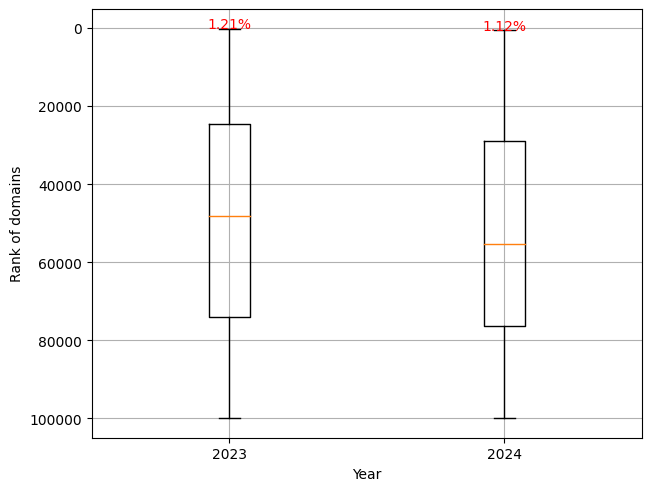

In [162]:
# Using Tranco 100k only 
# TMA extended work

import matplotlib.pyplot as plt
import pandas as pd

years = ["2023", "2024"]

data_dict = {}

for year in years:
    # For rest of the years, we use umbrella 1M list
    df = pd.read_csv("../data/after_tma/openintel_tranco_ip_domains_ranks_100k_01_jan_"+year+".csv")
    ranks = df["rank"].unique()
    data_dict[year] = ranks

fig, ax = plt.subplots(layout='constrained') # layout='constrained' is added because x-label was cut off before.
ax.boxplot(data_dict.values())

# Annotate with the number of samples
for i, (key, values) in enumerate(data_dict.items(), start=1):
    year = key
    
    no_of_total_domains = 100000
        
    percentage_domain = len(values)*100/no_of_total_domains
    percentage_domain = round(percentage_domain, 2)
    ax.text(i, min(values), f"{percentage_domain}%", ha='center', fontsize=10, color="red")

# Set x-axis labels
ax.set_xticklabels(data_dict.keys())

ax.set_xticklabels(data_dict.keys())
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Rank of domains", fontsize=10)
# Invert y-axis so that lower ranks are at the top
ax.invert_yaxis()
ax.grid()

# fig.suptitle("umbrella for 2020 to 2022", fontsize = 14)
fig.savefig("../images/correlating_tranco_100K.pdf")

No. of domains protected in 2020 is 1077
No. of domains protected in 2021 is 1224
No. of domains protected in 2022 is 1424
No. of domains protected in 2023 is 1213
No. of domains protected in 2024 is 1125


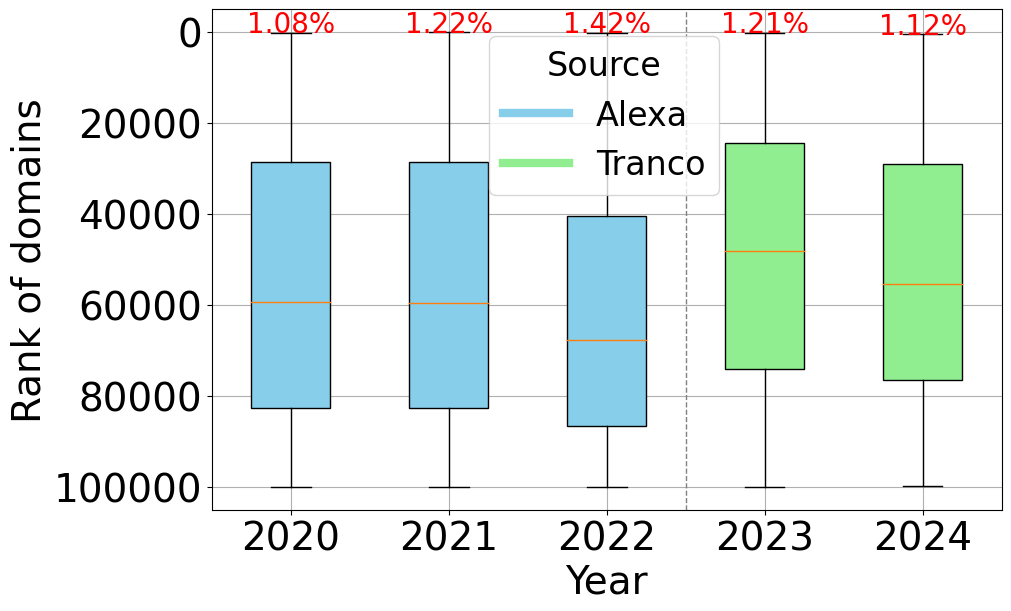

<Figure size 1200x800 with 0 Axes>

In [228]:
import matplotlib.pyplot as plt
import pandas as pd

years = ["2020", "2021", "2022", "2023", "2024"]
data_dict = {}
source_list = []

for year in years:
    if year in ["2020", "2021", "2022"]:
        df = pd.read_csv("../data/after_tma/openintel_alexa_ip_domains_ranks_100k_01_jan_" + year + ".csv")
        source_list.append("Alexa")
    else:
        df = pd.read_csv("../data/after_tma/openintel_tranco_ip_domains_ranks_100k_01_jan_" + year + ".csv")
        source_list.append("Tranco")
    unique_domains = df["rank"].unique()
#     print(f"No. of domains protected in {year} is {len(unique_domains)}")
    ranks = df["rank"].unique()
    data_dict[year] = ranks

fig, ax = plt.subplots(layout='constrained', figsize=(10, 6))

# Create the boxplot and keep the object
bp = ax.boxplot(data_dict.values(), patch_artist=True)

# Color based on source (Alexa or Tranco)
for i, (box, source) in enumerate(zip(bp['boxes'], source_list)):
    color = 'skyblue' if source == 'Alexa' else 'lightgreen'
    box.set_facecolor(color)

# Annotate percentage of domains found
for i, (key, values) in enumerate(data_dict.items(), start=1):
    no_of_total_domains = 100000
    percentage_domain = round(len(values) * 100 / no_of_total_domains, 2)
    ax.text(i, min(values), f"{percentage_domain}%", ha='center', fontsize=20, color="red")

# Set x-axis labels
ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(data_dict.keys(), fontsize=28)

# Axis labels
ax.set_xlabel("Year", fontsize=28)
ax.set_ylabel("Rank of domains", fontsize=28)

ax.tick_params(axis='both', labelsize=28)

# Invert y-axis so that lower ranks are at the top
ax.invert_yaxis()
ax.grid()

# Add vertical divider between Alexa and Tranco years
divider_index = source_list.index("Tranco") + 0.5
ax.axvline(divider_index, color='gray', linestyle='--', linewidth=1)

# Add custom legend
legend_handles = [
    plt.Line2D([0], [0], color='skyblue', lw=6, label='Alexa'),
    plt.Line2D([0], [0], color='lightgreen', lw=6, label='Tranco')
]
ax.legend(
    handles=legend_handles,
    fontsize = 24,
    loc='upper left',
    bbox_to_anchor=(0.33, 0.98),
#     ncol=2,
    title="Source", 
    title_fontsize=24,       # legend title

)

# Optional title
# fig.suptitle("Domain Rank Distribution: Alexa (2020–2022) vs Tranco (2023–2024)", fontsize=28)

fig.savefig("../images/correlating_alexa_tranco_100K_separated.pdf")
plt.figure(figsize=(12, 8))

plt.show()
